# 03 — Hane ve Demografi EDA'sı

## Amaç

Bu notebook, demografi kaydı bulunan hanelerin kategorik dağılımlarını inceler,
demografisi bulunan/bulunmayan hanelerin alışveriş davranışlarını karşılaştırır ve
demografik alanların modellemede nasıl kullanılacağına ilişkin bir deney stratejisi kurar.

### Cevaplanacak sorular

1. Demografi tablosu hane evreninin ne kadarını kapsıyor?
2. `Unknown` ve `None/Unknown` gibi belirsiz kategoriler hangi alanlarda yoğunlaşıyor?
3. Demografi kaydı bulunan haneler davranış bakımından diğer hanelerden ayrışıyor mu?
4. Ham aktivite farkları, aktif hafta başına normalize edildiğinde devam ediyor mu?
5. Demografi alanları ana modele hangi koşullarda eklenmeli?

## Kritik User Guide notu

`classification_1`, `classification_2` gibi alanlar bilinçli biçimde anonim ve genel
isimlerle verilmiştir. Bazı alanların değerleri anlamlı bir sıraya sahip olsa da veri
seti bu alanların gerçek hayattaki karşılığını açıklamaz.

Bu nedenle bu notebook'ta:

- `classification_1 = yaş`,
- `classification_2 = medeni durum`,
- `classification_3 = gelir`

gibi doğrulanmamış eşleştirmeler yapılmaz. Alanlar kendi anonim adlarıyla yorumlanır.

> Demografi tablosu yalnızca 801 haneyi kapsadığı için bütün proje evreni demografik
> kaydı bulunan hanelerle sınırlandırılmamalıdır. Parasal davranış metriğinde ise
> `02_` notebook'uyla tutarlı biçimde müşterinin tahmini ödediği tutar kullanılacaktır.


## 1. Kütüphaneler, yollar ve verinin yüklenmesi


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def first_existing_path(candidates):
    """İlk bulunan klasörü döndürür; bulunamazsa açıklayıcı hata verir."""
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Veri klasörü bulunamadı. Beklenen seçenekler: "
        + ", ".join(map(str, candidates))
    )


RAW_PATH = first_existing_path([
    "data/raw",
    "../data/raw",
    "data_raw",
    "../data_raw",
])

if RAW_PATH.name == "raw":
    DATA_ROOT = RAW_PATH.parent
else:
    DATA_ROOT = RAW_PATH.parent / "data"

PROCESSED_PATH = DATA_ROOT / "processed"
INTERIM_PATH = DATA_ROOT / "interim"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

print(f"Ham veri klasörü : {RAW_PATH.resolve()}")
print(f"İşlenmiş veri    : {PROCESSED_PATH.resolve()}")
print(f"Ara çıktılar     : {INTERIM_PATH.resolve()}")


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", palette="deep")


Ham veri klasörü : C:\Users\ed024981\Desktop\Miuul_project\data\raw
İşlenmiş veri    : C:\Users\ed024981\Desktop\Miuul_project\data\processed
Ara çıktılar     : C:\Users\ed024981\Desktop\Miuul_project\data\interim


In [2]:
def load_prepared_table(table_name):
    """Önce 01 notebook'unun ürettiği Parquet'i, yoksa ham CSV'yi okur."""
    parquet_path = INTERIM_PATH / f"{table_name}.parquet"
    csv_path = RAW_PATH / f"{table_name}.csv"

    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        source = parquet_path
    elif csv_path.exists():
        df = pd.read_csv(csv_path, low_memory=False)
        df.columns = (
            df.columns.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "_", regex=True)
        )
        source = csv_path
    else:
        raise FileNotFoundError(
            f"{table_name} için Parquet veya CSV bulunamadı. "
            "Önce 01_data_preparation.ipynb notebook'unu çalıştırın."
        )

    print(f"{table_name:20} <- {source} | {df.shape}")
    return df


In [3]:
transaction_data = load_prepared_table("transaction_data")
hh_demographic = load_prepared_table("hh_demographic")

required_transaction_cols = {
    "household_key", "basket_id", "day", "week_no", "product_id",
    "sales_value", "coupon_disc",
}
assert required_transaction_cols.issubset(transaction_data.columns), (
    "İşlem tablosunda gerekli sütunlar eksik."
)
assert hh_demographic["household_key"].is_unique, (
    "Demografi tablosunda household_key benzersiz olmalıdır."
)

# 02_ notebook'uyla aynı müşteri harcaması tanımı
transaction_data = transaction_data.copy()
transaction_data["customer_paid_value"] = (
    transaction_data["sales_value"]
    + transaction_data["coupon_disc"]
)
transaction_data["retailer_revenue"] = transaction_data["sales_value"]

demographic_cols = [
    col for col in hh_demographic.columns if col != "household_key"
]

print("Demografik alanlar:", demographic_cols)


transaction_data     <- ..\data\interim\transaction_data.parquet | (2595732, 12)
hh_demographic       <- ..\data\interim\hh_demographic.parquet | (801, 8)
Demografik alanlar: ['classification_1', 'classification_2', 'classification_3', 'homeowner_desc', 'classification_5', 'classification_4', 'kid_category_desc']


### Analiz birimi ve temel metrikler

Bu notebook'taki temel analiz birimi **hanedir (`household_key`)**. İşlem
satırları önce hane düzeyinde toplulaştırılır, ardından demografi kaydının
bulunup bulunmamasına göre karşılaştırılır.

Kullanılan temel davranış metrikleri:

- **Recency:** Hanenin son alışverişi ile veri döneminin son günü arasındaki gün sayısıdır.
  Daha düşük değer daha yakın tarihli alışverişi gösterir.
- **Frequency:** Hanenin gerçekleştirdiği benzersiz sepet sayısıdır.
- **Monetary:** Müşterinin kupon sonrası ödediği tahmini toplam tutardır.
  `sales_value + coupon_disc` biçiminde hesaplanır.
- **Aktif hafta:** Hanenin en az bir alışveriş yaptığı benzersiz hafta sayısıdır.
- **Gözlenen alışveriş süresi:** İlk ve son alışveriş arasındaki gün sayısıdır.
- **Aktif hafta başına sepet/harcama:** Farklı gözlem sürelerine ve aktivite
  seviyelerine sahip haneleri daha karşılaştırılabilir hale getiren normalize
  edilmiş göstergelerdir.

Parasal metriklerde `02_eda_transactions_and_products` notebook'uyla aynı tanım
kullanılarak notebook'lar arası tutarlılık korunmuştur.

## 2. Demografi tablosunun temel kalite kontrolü

Standart eksik değerlere ek olarak `Unknown`, `None/Unknown` ve boş string gibi
belirsizliği temsil eden kategoriler ayrıca raporlanır. Bu değerler silinmez. Özellikle
`None/Unknown`, “yok” ile “bilinmiyor” durumlarını birbirinden ayırmadığı için gerçek
bir eksik değer değil, **karma ve belirsiz bir kategori** olarak ele alınır.


In [4]:
def hidden_blank_count(dataframe):
    string_cols = dataframe.select_dtypes(include=["object", "string"]).columns
    if len(string_cols) == 0:
        return pd.Series(dtype="int64")
    counts = dataframe[string_cols].apply(
        lambda series: series.fillna("").astype(str).str.strip().eq("").sum()
    )
    return counts[counts > 0].sort_values(ascending=False)


quality_summary = pd.DataFrame({
    "dtype": hh_demographic.dtypes.astype(str),
    "missing": hh_demographic.isna().sum(),
    "unique": hh_demographic.nunique(dropna=False),
})
display(quality_summary)
display(hidden_blank_count(hh_demographic).to_frame("blank_string"))

unknown_or_ambiguous_values = {
    "unknown", "none/unknown", "none", "n/a", "na", "null", ""
}
placeholder_records = []

for col in demographic_cols:
    normalized = hh_demographic[col].fillna("").astype(str).str.strip().str.lower()
    count = int(normalized.isin(unknown_or_ambiguous_values).sum())
    placeholder_records.append({
        "column": col,
        "uncertain_category_count": count,
        "uncertain_category_ratio": count / len(hh_demographic),
    })

placeholder_summary = pd.DataFrame(placeholder_records).sort_values(
    "uncertain_category_ratio", ascending=False
)
placeholder_summary


,dtype,missing,unique
classification_1,str,0,6
classification_2,str,0,3
classification_3,str,0,12
homeowner_desc,str,0,5
classification_5,str,0,6
classification_4,str,0,5
kid_category_desc,str,0,4
household_key,int64,0,801


,blank_string


,column,uncertain_category_count,uncertain_category_ratio
6,kid_category_desc,558,0.697
3,homeowner_desc,233,0.291
0,classification_1,0,0.000
2,classification_3,0,0.000
1,classification_2,0,0.000
4,classification_5,0,0.000
5,classification_4,0,0.000


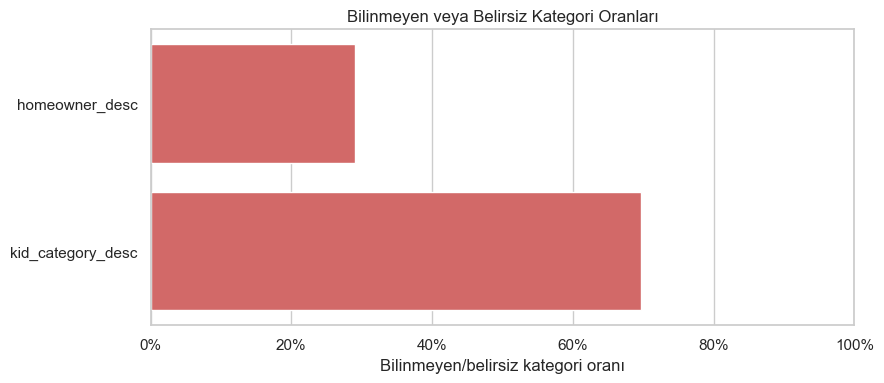

In [5]:
placeholder_plot = placeholder_summary.loc[
    placeholder_summary["uncertain_category_count"].gt(0)
].sort_values("uncertain_category_ratio")

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=placeholder_plot, x="uncertain_category_ratio", y="column", color="#E45756"
)
ax.set_xlim(0, 1)
ax.set_title("Bilinmeyen veya Belirsiz Kategori Oranları")
ax.set_xlabel("Bilinmeyen/belirsiz kategori oranı")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()


### Veri kalitesi bulguları

Demografi tablosunda standart `NaN` veya boş string biçiminde eksik değer
bulunmamaktadır. Bununla birlikte bazı kategoriler bilgi belirsizliği taşımaktadır:

- `kid_category_desc` alanındaki 558 kayıt (**%69,7**) `None/Unknown` değerindedir.
- `homeowner_desc` alanındaki 233 kayıt (**%29,1**) `Unknown` değerindedir.
- Diğer demografik alanlarda bilinmeyen veya belirsiz kategori tespit edilmemiştir.

Buradaki önemli ayrım, teknik eksiklik ile anlamsal belirsizlik arasındadır.
Örneğin `None/Unknown`, hanede çocuk olmadığını veya bilginin bilinmediğini
birlikte temsil eder. Bu iki durum birbirinden ayrılamadığı için kategori
silinmeyecek ve doğrudan “çocuk yok” şeklinde yorumlanmayacaktır.

### Analitik karar

- Belirsiz kategoriler ayrı bir kategori olarak korunacaktır.
- Bu kategorilere ortalama veya en sık görülen değerle atama yapılmayacaktır.
- Modelleme sırasında `Unknown` ve `None/Unknown` değerlerinin tahmine katkısı
  ayrıca kontrol edilecektir.

## 3. Demografik kapsama


In [6]:
transaction_households = pd.Index(transaction_data["household_key"].unique())
demographic_households = pd.Index(hh_demographic["household_key"].unique())

has_demographic_line = transaction_data["household_key"].isin(demographic_households)

coverage_summary = pd.Series({
    "all_transaction_households": len(transaction_households),
    "households_with_demographics": len(transaction_households.intersection(demographic_households)),
    "household_coverage_ratio": len(transaction_households.intersection(demographic_households)) / len(transaction_households),
    "transaction_line_coverage_ratio": has_demographic_line.mean(),
    "basket_coverage_ratio": (
        transaction_data.loc[has_demographic_line, "basket_id"].nunique()
        / transaction_data["basket_id"].nunique()
    ),
    "customer_spend_coverage_ratio": (
        transaction_data.loc[has_demographic_line, "customer_paid_value"].sum()
        / transaction_data["customer_paid_value"].sum()
    ),
})
coverage_summary


all_transaction_households        2,500.000
households_with_demographics        801.000
household_coverage_ratio              0.320
transaction_line_coverage_ratio       0.550
basket_coverage_ratio                 0.508
customer_spend_coverage_ratio         0.558
dtype: float64

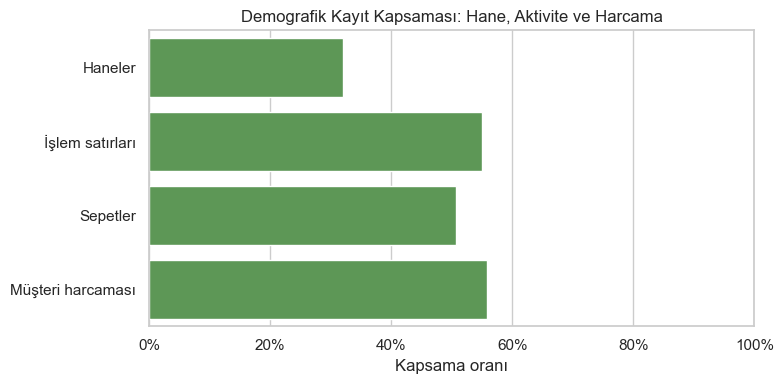

In [7]:
coverage_plot = pd.DataFrame({
    "Kapsama": ["Haneler", "İşlem satırları", "Sepetler", "Müşteri harcaması"],
    "Oran": [
        coverage_summary["household_coverage_ratio"],
        coverage_summary["transaction_line_coverage_ratio"],
        coverage_summary["basket_coverage_ratio"],
        coverage_summary["customer_spend_coverage_ratio"],
    ],
})

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=coverage_plot, x="Oran", y="Kapsama", color="#54A24B")
ax.set_xlim(0, 1)
ax.set_title("Demografik Kayıt Kapsaması: Hane, Aktivite ve Harcama")
ax.set_xlabel("Kapsama oranı")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()


### Neden birden fazla kapsama oranı hesaplanıyor?

- **Hane düzeyi kapsama**, kaç farklı hanenin demografi kaydı olduğunu gösterir.
- **İşlem satırı ve sepet kapsaması**, demografisi bulunan hanelerin alışveriş
  aktivitesindeki ağırlığını gösterir.
- **Müşteri harcaması kapsaması**, bu hanelerin müşterilerce ödenen toplam tutardaki
  payını gösterir.

İşlem kapsaması hane kapsamasından belirgin biçimde yüksekse, demografisi bulunan
haneler daha sık veya daha yüksek tutarda alışveriş yapıyor olabilir. Bu durum
demografik alt örneklemin bütün müşterileri temsil etmediğine işaret edebilir.


### Demografik kapsama sonuçları

| Kapsama ölçütü | Oran |
|---|---:|
| Demografi kaydı bulunan haneler | %32,0 |
| Bu hanelere ait işlem satırları | %55,0 |
| Bu hanelere ait sepetler | %50,8 |
| Bu hanelerin müşteri harcamasındaki payı | %55,8 |

Demografi tablosu 2.500 hanenin yalnızca 801'ini, yani **%32'sini** kapsamaktadır.
Buna karşılık bu haneler toplam sepetlerin **%50,8'ini** ve müşteri harcamasının
**%55,8'ini** oluşturmaktadır.

Bu fark, demografi kaydı bulunan hanelerin veri içindeki sıradan veya rastgele
seçilmiş bir alt örneklem olmayabileceğini göstermektedir. Sayıca az olmalarına
rağmen alışveriş aktivitesinde ve harcamada daha yüksek ağırlığa sahiptirler.

Bu nedenle yalnızca demografi kaydı bulunan 801 hane üzerinde kurulacak bir model,
daha aktif müşteri grubunu temsil ederek bütün 2.500 haneye genellenemeyebilir.
Ana müşteri evreni işlem tablosundaki bütün haneler olarak korunmalıdır.

## 4. Kategorik dağılımlar


In [8]:
def categorical_summary(dataframe, column):
    counts = dataframe[column].fillna("MISSING").value_counts(dropna=False)
    return pd.DataFrame({
        "count": counts,
        "ratio": counts / len(dataframe),
    })


for column in demographic_cols:
    print(f"\n### {column}")
    display(categorical_summary(hh_demographic, column))



### classification_1


,count,ratio
classification_1,,
Age Group4,288,0.360
Age Group3,194,0.242
Age Group2,142,0.177
Age Group6,72,0.090
Age Group5,59,0.074
Age Group1,46,0.057



### classification_2


,count,ratio
classification_2,,
Y,344,0.429
X,340,0.424
Z,117,0.146



### classification_3


...

,count,ratio
classification_5,,
Group5,255,0.318
Group4,187,0.233
Group3,144,0.180
Group2,95,0.119
Group6,73,0.091
Group1,47,0.059



### classification_4


,count,ratio
classification_4,,
2,318,0.397
1,255,0.318
3,109,0.136
5+,66,0.082
4,53,0.066



### kid_category_desc


,count,ratio
kid_category_desc,,
None/Unknown,558,0.697
1,114,0.142
3+,69,0.086
2,60,0.075


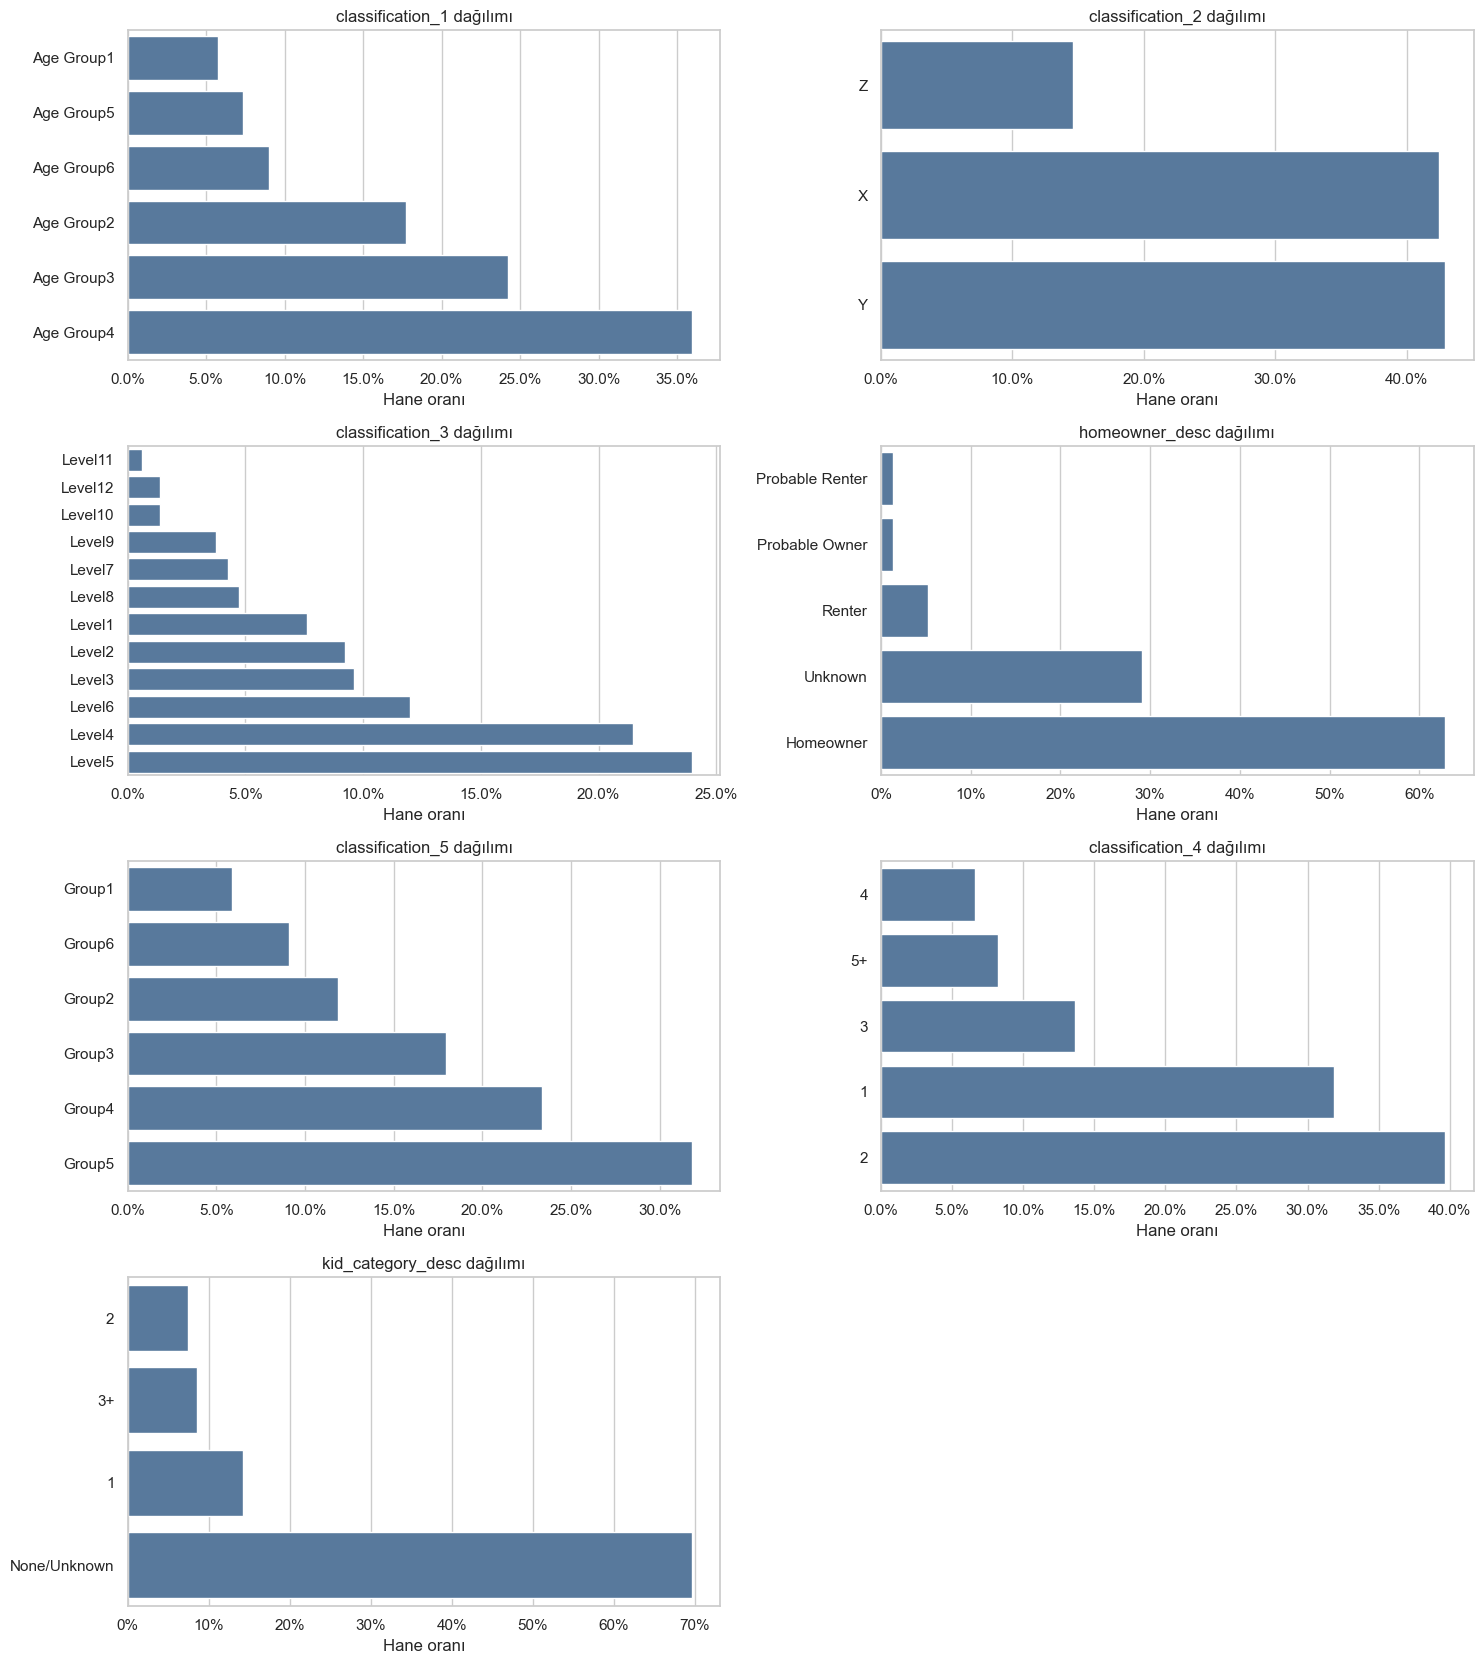

In [9]:
n_cols = 2
n_rows = int(np.ceil(len(demographic_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, demographic_cols):
    plot_data = (
        hh_demographic[column]
        .fillna("MISSING")
        .value_counts(normalize=True)
        .rename_axis("category")
        .reset_index(name="ratio")
        .sort_values("ratio")
    )
    sns.barplot(data=plot_data, x="ratio", y="category", ax=ax, color="#4C78A8")
    ax.set_title(f"{column} dağılımı")
    ax.set_xlabel("Hane oranı")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))

for ax in axes[len(demographic_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### Kategorik dağılımlara ilişkin bulgular

Demografik kategoriler dengeli dağılmamaktadır:

- `classification_1` içinde `Age Group4` tek başına 288 haneyi (**%36,0**)
  temsil etmektedir. En küçük kategori `Age Group1` olup 46 haneden oluşmaktadır.
- `classification_2` alanında `X` ve `Y` kategorileri benzer büyüklüktedir
  (**%42,4** ve **%42,9**); `Z` kategorisinin payı **%14,6**'dır.
- `classification_3` toplam 12 kategori içerir. `Level4` ve `Level5` birlikte
  hanelerin yaklaşık **%45,5**'ini oluştururken `Level10`, `Level11` ve
  `Level12` kategorilerinin örneklem büyüklükleri oldukça küçüktür.
- `homeowner_desc` alanında `Homeowner` kategorisi **%62,9** ile baskındır.
  Bununla birlikte kayıtların **%29,1**'inde ev sahipliği bilgisi bilinmemektedir.
- `classification_4` içinde `1` ve `2` kategorileri birlikte hanelerin
  **%71,5**'ini oluşturmaktadır.
- `kid_category_desc` alanının **%69,7'si** `None/Unknown` kategorisindedir.

### Yorumlama sınırı

Bu dağılımlar yalnızca demografi kaydı bulunan 801 haneyi temsil eder; bütün
2.500 hanelik müşteri evreninin demografik dağılımı olarak yorumlanamaz.

Ayrıca anonim `classification_*` alanlarına User Guide tarafından doğrulanmayan
gerçek dünya anlamları yüklenmemelidir. Örneğin “`Age Group4` en sık görülen
kategoridir” denebilir; ancak bu kategorinin belirli bir yaş aralığını temsil
ettiği varsayılamaz.

## 5. Demografisi bulunan ve bulunmayan hanelerin karşılaştırılması


Bu bölümde demografi kaydı bulunan 801 hane ile demografi kaydı bulunmayan
1.699 hane karşılaştırılır.

Harcama, sepet sayısı ve ürün çeşitliliği sağa çarpık dağıldığı için gruplar
**ortalama yerine medyan değerlerle** karşılaştırılmıştır. Medyan, az sayıdaki
çok yüksek harcamalı veya çok sık alışveriş yapan haneden daha az etkilenir.

Yalnızca toplam sepet ve harcamaya bakmak yeterli değildir. Daha uzun süre aktif
olan bir hanenin doğal olarak daha fazla sepet ve harcama üretmesi beklenir.
Bu nedenle karşılaştırmaya aşağıdaki normalize edilmiş metrikler de eklenmiştir:

- Aktif hafta başına sepet sayısı
- Aktif hafta başına müşteri harcaması
- Ortalama sepet tutarı

Böylece toplam aktivite ile alışveriş yoğunluğu birbirinden ayrılmaya çalışılır.

In [10]:
household_behavior = (
    transaction_data.groupby("household_key")
    .agg(
        first_purchase_day=("day", "min"),
        last_purchase_day=("day", "max"),
        frequency=("basket_id", "nunique"),
        monetary=("customer_paid_value", "sum"),
        retailer_revenue=("retailer_revenue", "sum"),
        active_days=("day", "nunique"),
        active_weeks=("week_no", "nunique"),
        unique_products=("product_id", "nunique"),
    )
    .reset_index()
)

data_end_day = int(transaction_data["day"].max())
household_behavior["recency"] = data_end_day - household_behavior["last_purchase_day"]
household_behavior["purchase_span_days"] = (
    household_behavior["last_purchase_day"]
    - household_behavior["first_purchase_day"]
    + 1
)
household_behavior["avg_basket_value"] = household_behavior["monetary"] / household_behavior["frequency"]
household_behavior["baskets_per_active_week"] = (
    household_behavior["frequency"] / household_behavior["active_weeks"]
)
household_behavior["spend_per_active_week"] = (
    household_behavior["monetary"] / household_behavior["active_weeks"]
)
household_behavior["has_demographic"] = household_behavior["household_key"].isin(demographic_households)

demographic_comparison = (
    household_behavior.groupby("has_demographic")
    .agg(
        household_count=("household_key", "nunique"),
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median"),
        median_monetary=("monetary", "median"),
        median_purchase_span_days=("purchase_span_days", "median"),
        median_active_weeks=("active_weeks", "median"),
        median_unique_products=("unique_products", "median"),
        median_avg_basket_value=("avg_basket_value", "median"),
        median_baskets_per_active_week=("baskets_per_active_week", "median"),
        median_spend_per_active_week=("spend_per_active_week", "median"),
    )
    .reset_index()
)
demographic_comparison


,has_demographic,household_count,median_recency,median_frequency,median_monetary,median_purchase_span_days,median_active_weeks,median_unique_products,median_avg_basket_value,median_baskets_per_active_week,median_spend_per_active_week
0,False,1699,9.000,52.000,"1,392.240",622.000,36.000,327.000,25.280,1.452,41.020
1,True,801,2.000,139.000,"4,645.310",636.000,73.000,803.000,32.105,1.968,68.470


,Metrik,Demografi var / yok oranı
0,Recency,0.222
3,Gözlenen alışveriş süresi,1.023
6,Ortalama sepet,1.270
7,Aktif hafta başına sepet,1.355
8,Aktif hafta başına harcama,1.669
4,Aktif hafta,2.028
5,Farklı ürün,2.456
1,Sepet sayısı,2.673
2,Müşteri harcaması,3.337


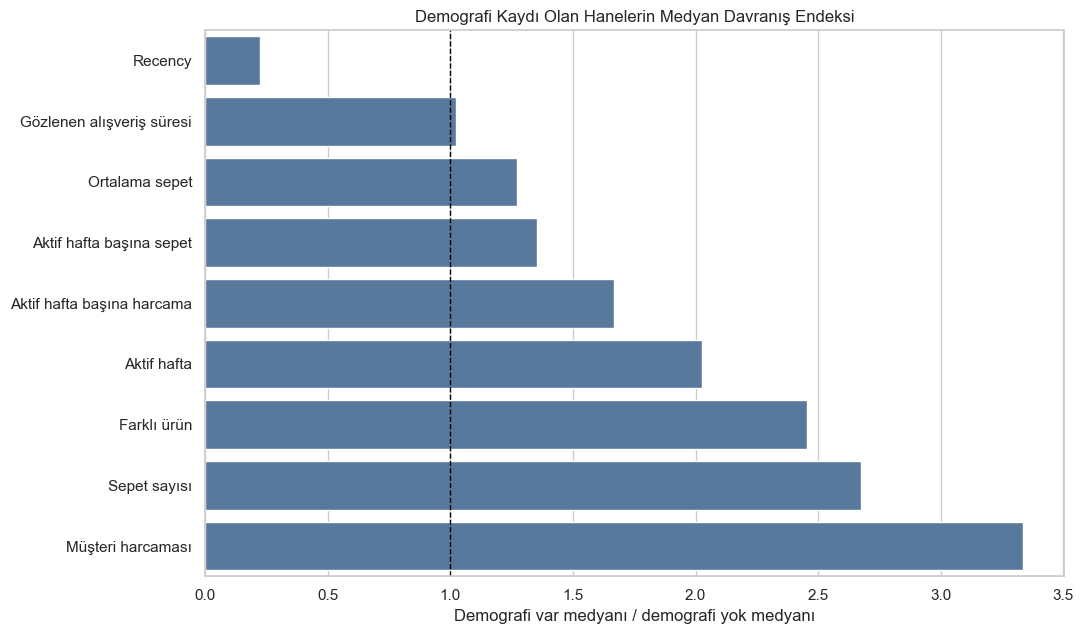

In [11]:
ratio_metrics = {
    "Recency": "median_recency",
    "Sepet sayısı": "median_frequency",
    "Müşteri harcaması": "median_monetary",
    "Gözlenen alışveriş süresi": "median_purchase_span_days",
    "Aktif hafta": "median_active_weeks",
    "Farklı ürün": "median_unique_products",
    "Ortalama sepet": "median_avg_basket_value",
    "Aktif hafta başına sepet": "median_baskets_per_active_week",
    "Aktif hafta başına harcama": "median_spend_per_active_week",
}

without_demo = demographic_comparison.set_index("has_demographic").loc[False]
with_demo = demographic_comparison.set_index("has_demographic").loc[True]
selection_index = pd.DataFrame({
    "Metrik": list(ratio_metrics),
    "Demografi var / yok oranı": [
        with_demo[column] / without_demo[column]
        for column in ratio_metrics.values()
    ],
}).sort_values("Demografi var / yok oranı")

display(selection_index)

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(
    data=selection_index,
    x="Demografi var / yok oranı", y="Metrik", color="#4C78A8"
)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set_title("Demografi Kaydı Olan Hanelerin Medyan Davranış Endeksi")
ax.set_xlabel("Demografi var medyanı / demografi yok medyanı")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


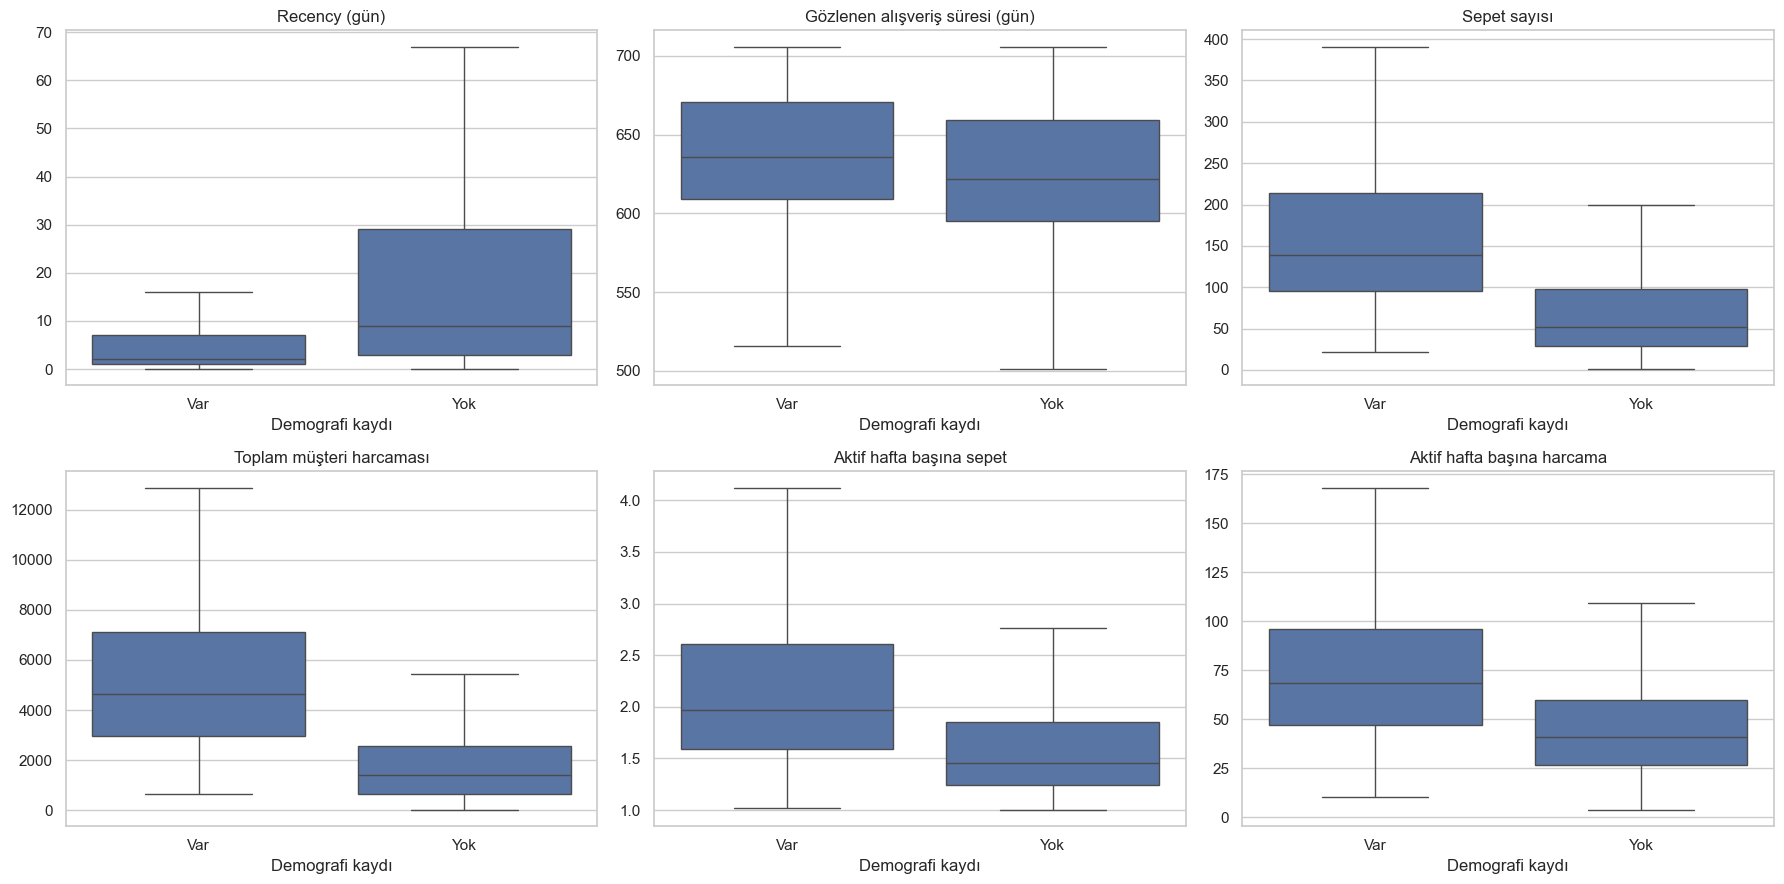

In [12]:
compare_cols = [
    "recency", "purchase_span_days", "frequency", "monetary",
    "baskets_per_active_week", "spend_per_active_week",
]
metric_labels = {
    "recency": "Recency (gün)",
    "purchase_span_days": "Gözlenen alışveriş süresi (gün)",
    "frequency": "Sepet sayısı",
    "monetary": "Toplam müşteri harcaması",
    "baskets_per_active_week": "Aktif hafta başına sepet",
    "spend_per_active_week": "Aktif hafta başına harcama",
}
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

plot_df = household_behavior.copy()
plot_df["Demografi kaydı"] = plot_df["has_demographic"].map({
    True: "Var", False: "Yok"
})

for ax, col in zip(axes.flat, compare_cols):
    clipped = plot_df.copy()
    clipped[col] = clipped[col].clip(upper=clipped[col].quantile(0.99))
    sns.boxplot(data=clipped, x="Demografi kaydı", y=col, ax=ax, showfliers=False)
    ax.set_title(metric_labels[col])
    ax.set_xlabel("Demografi kaydı")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


### Demografi kapsamına göre davranış farklılıkları

| Medyan metrik | Demografi yok | Demografi var | Var / yok oranı |
|---|---:|---:|---:|
| Recency | 9 gün | 2 gün | 0,22 |
| Gözlenen alışveriş süresi | 622 gün | 636 gün | 1,02 |
| Sepet sayısı | 52 | 139 | 2,67 |
| Müşteri harcaması | 1.392,24 | 4.645,31 | 3,34 |
| Aktif hafta | 36 | 73 | 2,03 |
| Farklı ürün sayısı | 327 | 803 | 2,46 |
| Ortalama sepet tutarı | 25,28 | 32,11 | 1,27 |
| Aktif hafta başına sepet | 1,45 | 1,97 | 1,36 |
| Aktif hafta başına harcama | 41,02 | 68,47 | 1,67 |

Demografi kaydı bulunan ve bulunmayan hanelerin gözlenen alışveriş süreleri
birbirine oldukça yakındır: medyan değerler sırasıyla 636 ve 622 gündür.
Dolayısıyla gruplar arasındaki büyük harcama farkı yalnızca veri içinde daha
uzun süre görünmekle açıklanamamaktadır.

Demografi kaydı bulunan haneler:

- Son alışverişleri veri döneminin sonuna daha yakındır. Medyan recency
  9 günden 2 güne düşmekte, yani yaklaşık **%77,8 daha düşük** görünmektedir.
- Yaklaşık **2 kat daha fazla aktif haftaya** sahiptir.
- **2,67 kat daha fazla sepet** oluşturmuştur.
- **3,34 kat daha yüksek toplam müşteri harcamasına** sahiptir.
- Aktif oldukları haftalarda **%35,5 daha fazla sepet** oluşturmuştur.
- Aktif hafta başına **%66,9 daha fazla harcama** yapmıştır.
- Ortalama sepet tutarları yaklaşık **%27 daha yüksektir**.

Normalize edilmiş metriklerde de farkın devam etmesi, ayrışmanın yalnızca
gözlem süresinden kaynaklanmadığını; demografi kaydı bulunan hanelerin daha
düzenli ve yoğun alışveriş davranışı gösterdiğini düşündürmektedir.

Bu sonuç nedensellik göstermez. Demografi kaydının neden daha aktif hanelerde
bulunduğu bilinmemektedir. Ancak demografik eksikliğin gözlenen müşteri
davranışıyla ilişkili olduğuna dair güçlü bir işarettir.

## 6. Demografik kategoriler ile davranış ilişkisi


In [13]:
household_demo = hh_demographic.merge(
    household_behavior.drop(columns="has_demographic"),
    on="household_key",
    how="left",
    validate="one_to_one",
)
assert household_demo["monetary"].notna().all(), (
    "Demografi tablosundaki bazı hanelerin işlem davranışı bulunamadı."
)

def demographic_behavior_profile(dataframe, column):
    return (
        dataframe.groupby(column, dropna=False)
        .agg(
            household_count=("household_key", "nunique"),
            median_recency=("recency", "median"),
            median_frequency=("frequency", "median"),
            median_monetary=("monetary", "median"),
            median_active_weeks=("active_weeks", "median"),
            median_baskets_per_active_week=("baskets_per_active_week", "median"),
            median_spend_per_active_week=("spend_per_active_week", "median"),
        )
        .reset_index()
    )


demographic_profiles = {
    column: demographic_behavior_profile(household_demo, column)
    for column in demographic_cols
}

for column, profile in demographic_profiles.items():
    print(f"\n### {column}")
    display(profile)



### classification_1


,classification_1,household_count,median_recency,median_frequency,median_monetary,median_active_weeks,median_baskets_per_active_week,median_spend_per_active_week
0,Age Group1,46,2.000,156.500,"4,011.420",70.500,2.032,58.556
1,Age Group2,142,2.000,135.500,"4,689.395",71.000,1.920,65.673
2,Age Group3,194,2.000,147.000,"5,486.670",73.500,1.982,78.932
3,Age Group4,288,3.000,141.500,"4,693.460",74.000,1.974,69.358
4,Age Group5,59,2.000,157.000,"4,195.950",75.000,1.986,65.852
5,Age Group6,72,3.000,124.000,"3,500.940",72.000,1.816,57.326



### classification_2


,classification_2,household_count,median_recency,median_frequency,median_monetary,median_active_weeks,median_baskets_per_active_week,median_spend_per_active_week
0,X,340,2.500,132.000,"5,031.230",72.500,1.926,76.083
1,Y,344,3.000,152.000,"4,442.950",74.000,2.050,65.263
2,Z,117,2.000,133.000,"4,524.710",72.000,1.870,62.761



### classification_3


...

,classification_5,household_count,median_recency,median_frequency,median_monetary,median_active_weeks,median_baskets_per_active_week,median_spend_per_active_week
0,Group1,47,2.000,158.000,"5,255.370",74.000,2.000,76.582
1,Group2,95,2.000,155.000,"3,979.100",74.000,1.976,62.626
2,Group3,144,3.000,128.500,"4,447.390",71.500,1.807,61.964
3,Group4,187,2.000,137.000,"5,514.520",74.000,1.957,76.481
4,Group5,255,3.000,138.000,"4,795.030",72.000,1.937,72.481
5,Group6,73,3.000,153.000,"4,714.890",74.000,2.103,64.355



### classification_4


,classification_4,household_count,median_recency,median_frequency,median_monetary,median_active_weeks,median_baskets_per_active_week,median_spend_per_active_week
0,1,255,2.000,150.000,"4,405.170",74.000,2.012,63.689
1,2,318,3.000,136.000,"4,610.855",71.500,1.923,71.847
2,3,109,2.000,138.000,"4,744.890",74.000,1.982,70.312
3,4,53,2.000,135.000,"5,918.030",72.000,2.016,83.154
4,5+,66,2.000,130.000,"5,366.960",68.500,1.954,84.749



### kid_category_desc


,kid_category_desc,household_count,median_recency,median_frequency,median_monetary,median_active_weeks,median_baskets_per_active_week,median_spend_per_active_week
0,1,114,2.000,140.000,"4,625.480",74.000,1.975,69.556
1,2,60,2.000,142.500,"5,972.905",74.000,2.054,83.850
2,3+,69,2.000,131.000,"5,514.520",70.000,1.957,85.313
3,None/Unknown,558,3.000,140.500,"4,525.715",73.000,1.958,66.329


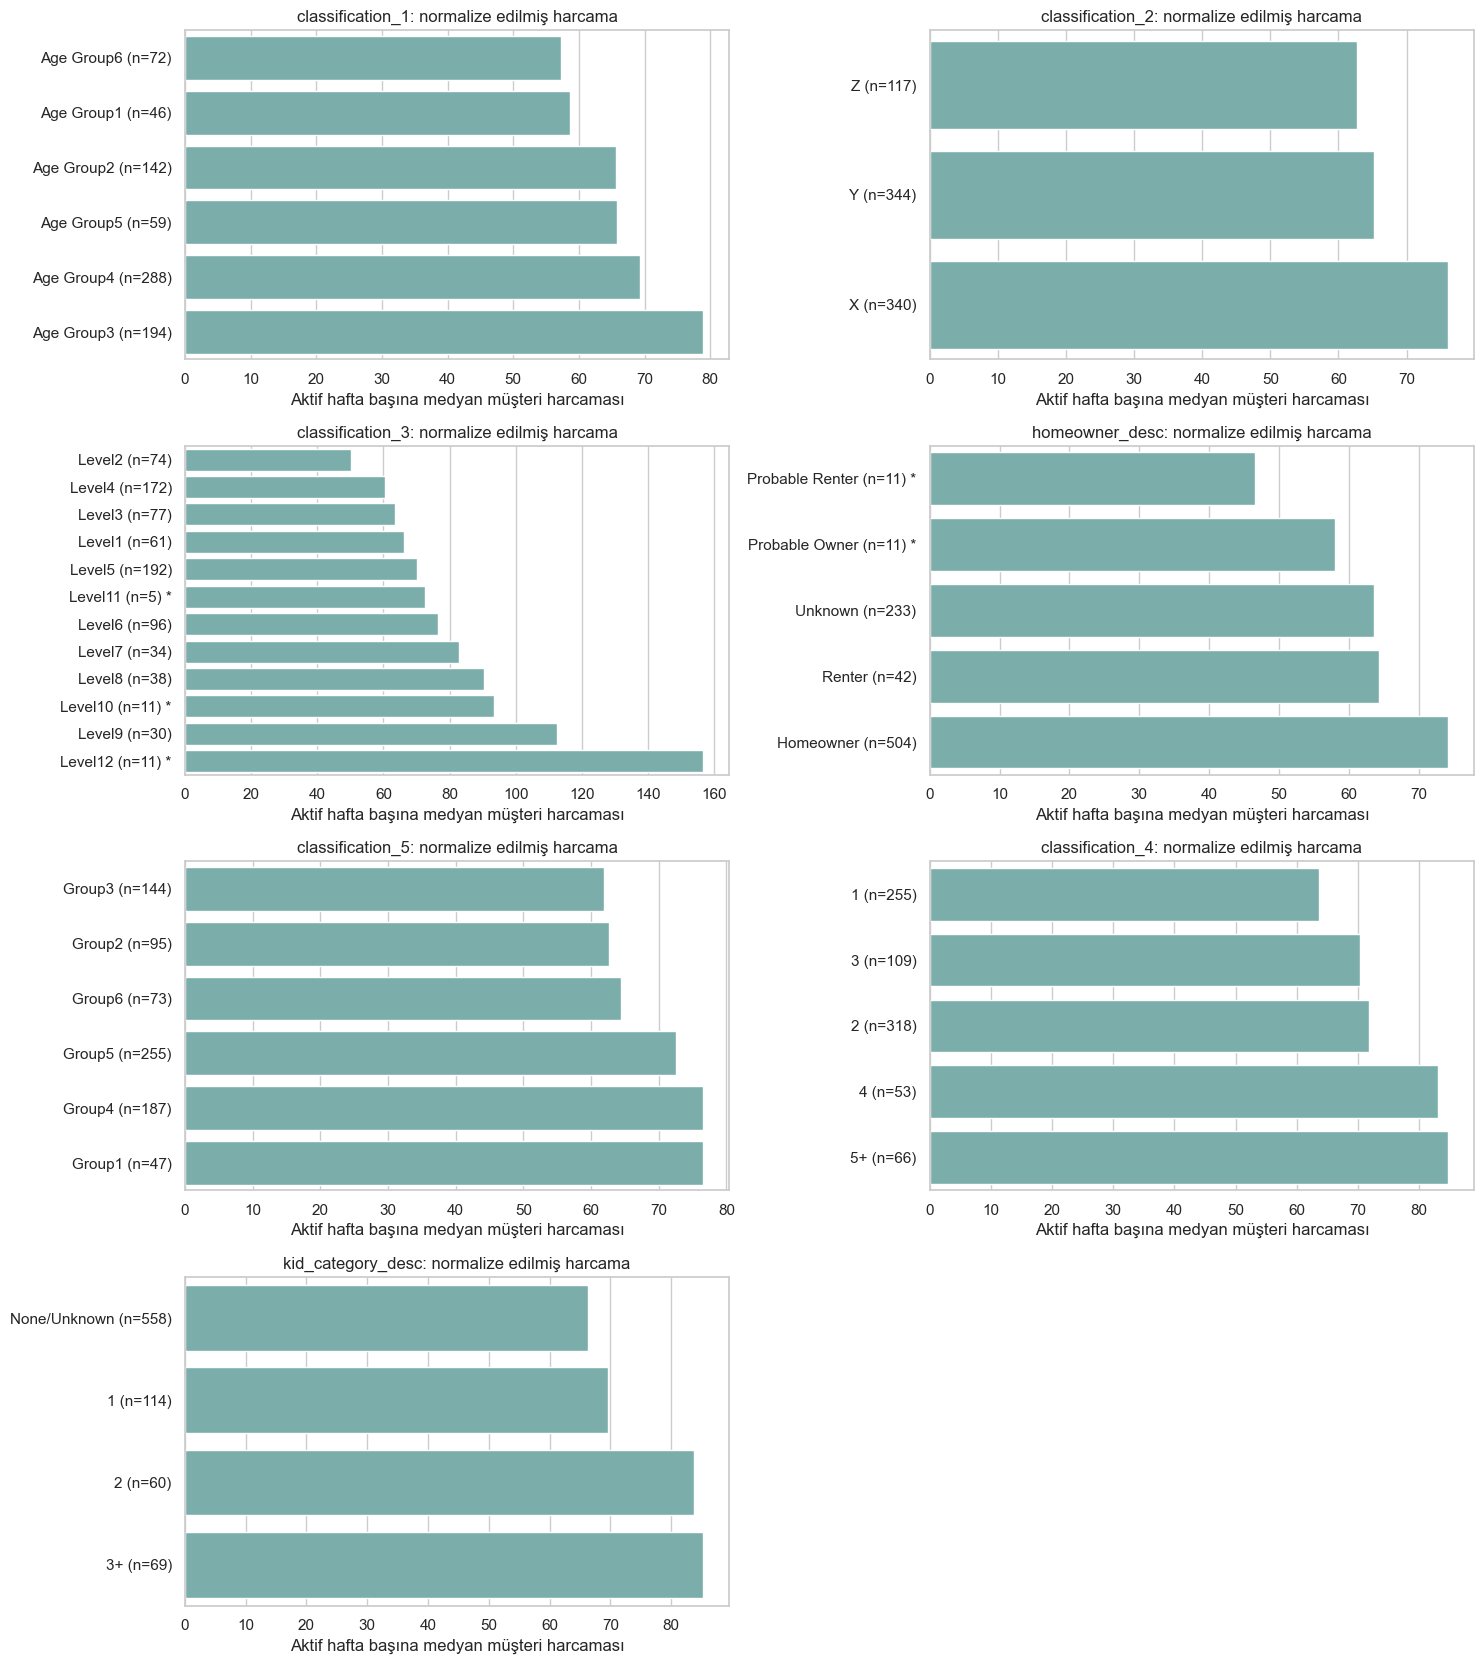

* n < 30: küçük örneklem; sonuç keşifsel yorumlanmalıdır.


In [14]:
profile_candidates = [
    col for col in demographic_cols
    if hh_demographic[col].nunique(dropna=True) <= 12
]

n_cols = 2
n_rows = int(np.ceil(len(profile_candidates) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, profile_candidates):
    profile = demographic_profiles[column].copy()
    profile["category_label"] = (
        profile[column].astype(str)
        + " (n=" + profile["household_count"].astype(str) + ")"
        + np.where(profile["household_count"].lt(30), " *", "")
    )
    profile = profile.sort_values("median_spend_per_active_week")
    sns.barplot(
        data=profile, x="median_spend_per_active_week",
        y="category_label", ax=ax, color="#72B7B2"
    )
    ax.set_title(f"{column}: normalize edilmiş harcama")
    ax.set_xlabel("Aktif hafta başına medyan müşteri harcaması")
    ax.set_ylabel("")

for ax in axes[len(profile_candidates):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print("* n < 30: küçük örneklem; sonuç keşifsel yorumlanmalıdır.")


### Demografik kategoriler ile normalize edilmiş harcama ilişkisi

Grafiklerde toplam harcama yerine **aktif hafta başına medyan müşteri harcaması**
kullanılmıştır. Böylece uzun süre aktif kalan hanelerin otomatik olarak daha
yüksek değer almasının etkisi azaltılmıştır.

Öne çıkan tanımlayıcı bulgular:

- `classification_1` kategorilerinde aktif hafta başına harcama yaklaşık
  57–79 aralığındadır. En yüksek değer `Age Group3`, en düşük değer ise
  `Age Group6` kategorisindedir.
- `classification_2` içinde `X` kategorisi 76,08 ile `Y` ve `Z`
  kategorilerinden daha yüksek normalize edilmiş harcamaya sahiptir.
- `classification_3` içinde `Level12` en yüksek değeri göstermektedir; ancak
  bu kategori yalnızca 11 haneden oluştuğu için sonuç kararlı kabul edilmemelidir.
- `homeowner_desc` içinde `Homeowner` grubunun medyan değeri 74,18; `Unknown`
  grubunun değeri ise 63,55'tir. `Probable Owner` ve `Probable Renter`
  gruplarında yalnızca 11'er hane bulunduğu için karşılaştırmalar sınırlıdır.
- `classification_4` içinde `4` ve `5+` kategorilerinin aktif hafta başına
  harcamaları diğer kategorilerden daha yüksektir.
- `kid_category_desc` içinde `2` ve `3+` kategorileri daha yüksek harcama
  göstermektedir. Ancak `None/Unknown` kategorisi iki farklı durumu bir arada
  içerdiği için güvenli bir referans grup değildir.

Kategori adlarının yanında örneklem büyüklüğü (`n`) gösterilmiştir. Yıldızlı
kategorilerde `n < 30` olduğu için bu sonuçlar yalnızca keşifsel bulgu olarak
değerlendirilmelidir.

Bu farklar demografik kategorilerin müşteri davranışıyla ilişkili olabileceğini
gösterir; kategorilerin yüksek harcamaya neden olduğunu göstermez. Modelleme
aşamasında demografi özelliklerinin katkısı doğrulama performansıyla ölçülmelidir.

## 7. Modelleme için demografi kullanım stratejisi

Önerilen yaklaşım, demografinin katkısını tek bir modele peşinen kabul etmek yerine
üç karşılaştırılabilir deneyle ölçmektir:

1. **Ana model:** Bütün 2.500 hanede yalnızca davranışsal özellikler.
2. **Ek özellik deneyi:** Bütün hanelerde `has_demographic` ve `left join` ile eklenen
   demografi alanları; eksik kayıtlar `NO_DEMOGRAPHIC_RECORD` kategorisiyle temsil edilir.
3. **Alt örneklem deneyi:** Yalnızca demografi kaydı bulunan 801 hanede davranış +
   demografi özellikleri.

Deneyler aynı zaman bazlı doğrulama düzeninde karşılaştırılmalıdır. `has_demographic`
veri toplama sürecini temsil eden güçlü bir vekil değişken olabileceği için ana modele
otomatik olarak alınmamalı; katkısı ablasyon karşılaştırmasıyla raporlanmalıdır.

Aşağıdaki hücre, bütün haneleri koruyan EDA amaçlı bir müşteri-demografi tablosu
oluşturur. Bu tablo bütün veri dönemini kullandığı için doğrudan model girdisi değildir;
nihai özellikler gözlem penceresinde yeniden üretilecektir.


In [15]:
customer_demographic_eda = household_behavior.merge(
    hh_demographic,
    on="household_key",
    how="left",
    validate="one_to_one",
)

for column in demographic_cols:
    customer_demographic_eda[column] = (
        customer_demographic_eda[column]
        .astype("string")
        .fillna("NO_DEMOGRAPHIC_RECORD")
    )

customer_demographic_eda.to_parquet(
    INTERIM_PATH / "customer_demographic_eda.parquet",
    index=False,
)

assert customer_demographic_eda["household_key"].is_unique
assert len(customer_demographic_eda) == transaction_data["household_key"].nunique()

print(customer_demographic_eda.shape)
customer_demographic_eda.head()


(2500, 22)


,household_key,first_purchase_day,last_purchase_day,frequency,monetary,retailer_revenue,active_days,active_weeks,unique_products,recency,purchase_span_days,avg_basket_value,baskets_per_active_week,spend_per_active_week,has_demographic,classification_1,classification_2,classification_3,homeowner_desc,classification_5,classification_4,kid_category_desc
0,1,51,706,86,"4,249.600","4,330.160",79,68,677,5,656,49.414,1.265,62.494,True,Age Group6,X,Level4,Homeowner,Group5,2,None/Unknown
1,2,103,668,45,"1,945.340","1,954.340",45,35,546,43,566,43.230,1.286,55.581,False,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD
2,3,113,703,47,"2,592.020","2,653.210",46,37,516,8,591,55.149,1.270,70.055,False,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD
3,4,104,627,30,"1,197.610","1,200.110",30,26,164,84,524,39.920,1.154,46.062,False,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD
4,5,85,703,40,779.060,779.060,33,27,199,8,619,19.477,1.481,28.854,False,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD,NO_DEMOGRAPHIC_RECORD


## Sonuç ve modelleme kararı

### Bir bakışta temel sonuç

Demografi yalnızca hanelerin **%32'sinde** bulunmaktadır; ancak bu müşteriler
sepetlerin **%50,8'ini** ve müşteri harcamasının **%55,8'ini** oluşturmaktadır.
Demografi kaydı olan hanelerin gözlenen alışveriş süreleri diğer hanelerle
neredeyse aynı olmasına rağmen toplam harcamaları **3,34 kat**, aktif hafta
başına harcamaları ise **1,67 kat** daha yüksektir.

Bu nedenle demografi kaydı bulunan 801 hane, bütün müşteri evrenini temsil eden
rastgele bir alt örneklem olarak kabul edilmemelidir.

### Kapsama ve veri kalitesi

- Demografik veri 2.500 hanenin yalnızca **801'ini (%32,0)** kapsar; fakat bu
  haneler işlem satırlarının yaklaşık **%55,0'ını** üretir.
- `kid_category_desc` alanında 558 kayıt (**%69,7**) `None/Unknown`, ev sahipliği
  alanında 233 kayıt (**%29,1**) `Unknown` değerindedir. `None/Unknown` doğrudan
  “çocuk yok” veya tamamen “eksik” şeklinde yorumlanamaz; karma bir kategoridir.
- Anonim `classification_*` alanlarına User Guide'da açıklanmayan yaş, gelir veya
  medeni durum anlamları yüklenmemiştir.

### Temsil farklılığı

`demographic_comparison` tablosu ham recency, sepet, harcama ve aktiflik
metriklerini; ayrıca aktif hafta başına normalize edilmiş yoğunluk göstergelerini
birlikte sunar. Ham toplamlar belirgin biçimde ayrışsa bile bunun ne kadarının daha
uzun gözlenen alışveriş süresinden, ne kadarının daha yoğun aktiviteden geldiği
normalize edilmiş metriklerle değerlendirilmelidir. Farklar demografi kaydının
rastgele eksik olmayabileceğine işaret eder; nedenini tek başına kanıtlamaz.

### Modelleme kararı

Ana model bütün 2.500 hanede davranışsal özelliklerle kurulmalıdır. Demografi
`left join` ile yalnızca ek deneyde kullanılmalı; `has_demographic` göstergesinin
katkısı ve olası veri-toplama vekili etkisi ayrıca ölçülmelidir. Yalnızca 801 haneyi
kapsayan demografik model ayrı bir alt örneklem deneyi olarak raporlanmalıdır.

Kaçınılması gereken ifade:

> “Veri seti orta yaş ve orta gelir grubundan oluşuyor.”

Kullanılabilecek ifade:

> “Demografi kaydı bulunan 801 hanede `classification_1` ve
> `classification_3` kategorileri dengesiz dağılmaktadır; ancak bu anonim alanların
> gerçek dünyadaki karşılıkları User Guide'da açıklanmamıştır.”

**Sonraki adım:** `04_eda_campaigns_and_coupons.ipynb` ile kampanya maruziyeti ve
kupon kullanım davranışı incelenecektir.
